# 🔵 21 - Polar Plots & Circular Data Visualization

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 8)

print("✅ Libraries imported")

✅ Libraries imported


## 🎯 Learning Objectives

- Creating polar coordinate plots
- Plotting circular/radial data
- Rose plots and wind roses
- Spiral patterns in polar coordinates
- Radar charts for multi-dimensional data

## 📐 1. Basic Polar Plot

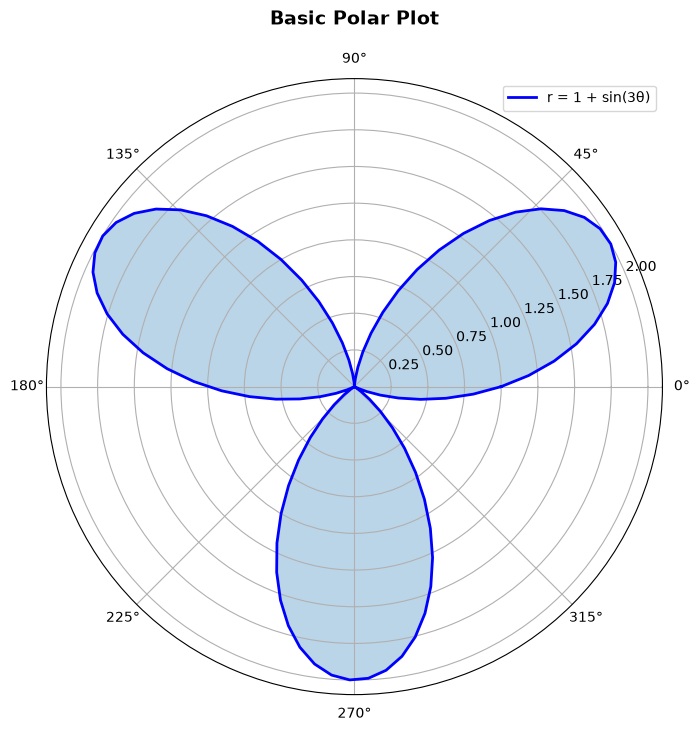

In [2]:
# Create theta (angles) and r (radius) data
theta = np.linspace(0, 2*np.pi, 100)
r = 1 + np.sin(3*theta)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='polar')

ax.plot(theta, r, 'b-', linewidth=2, label='r = 1 + sin(3θ)')
ax.fill(theta, r, alpha=0.3)

ax.set_title('Basic Polar Plot', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right')
ax.grid(True)

plt.show()

## 🌹 2. Rose Plot (Flower Pattern)

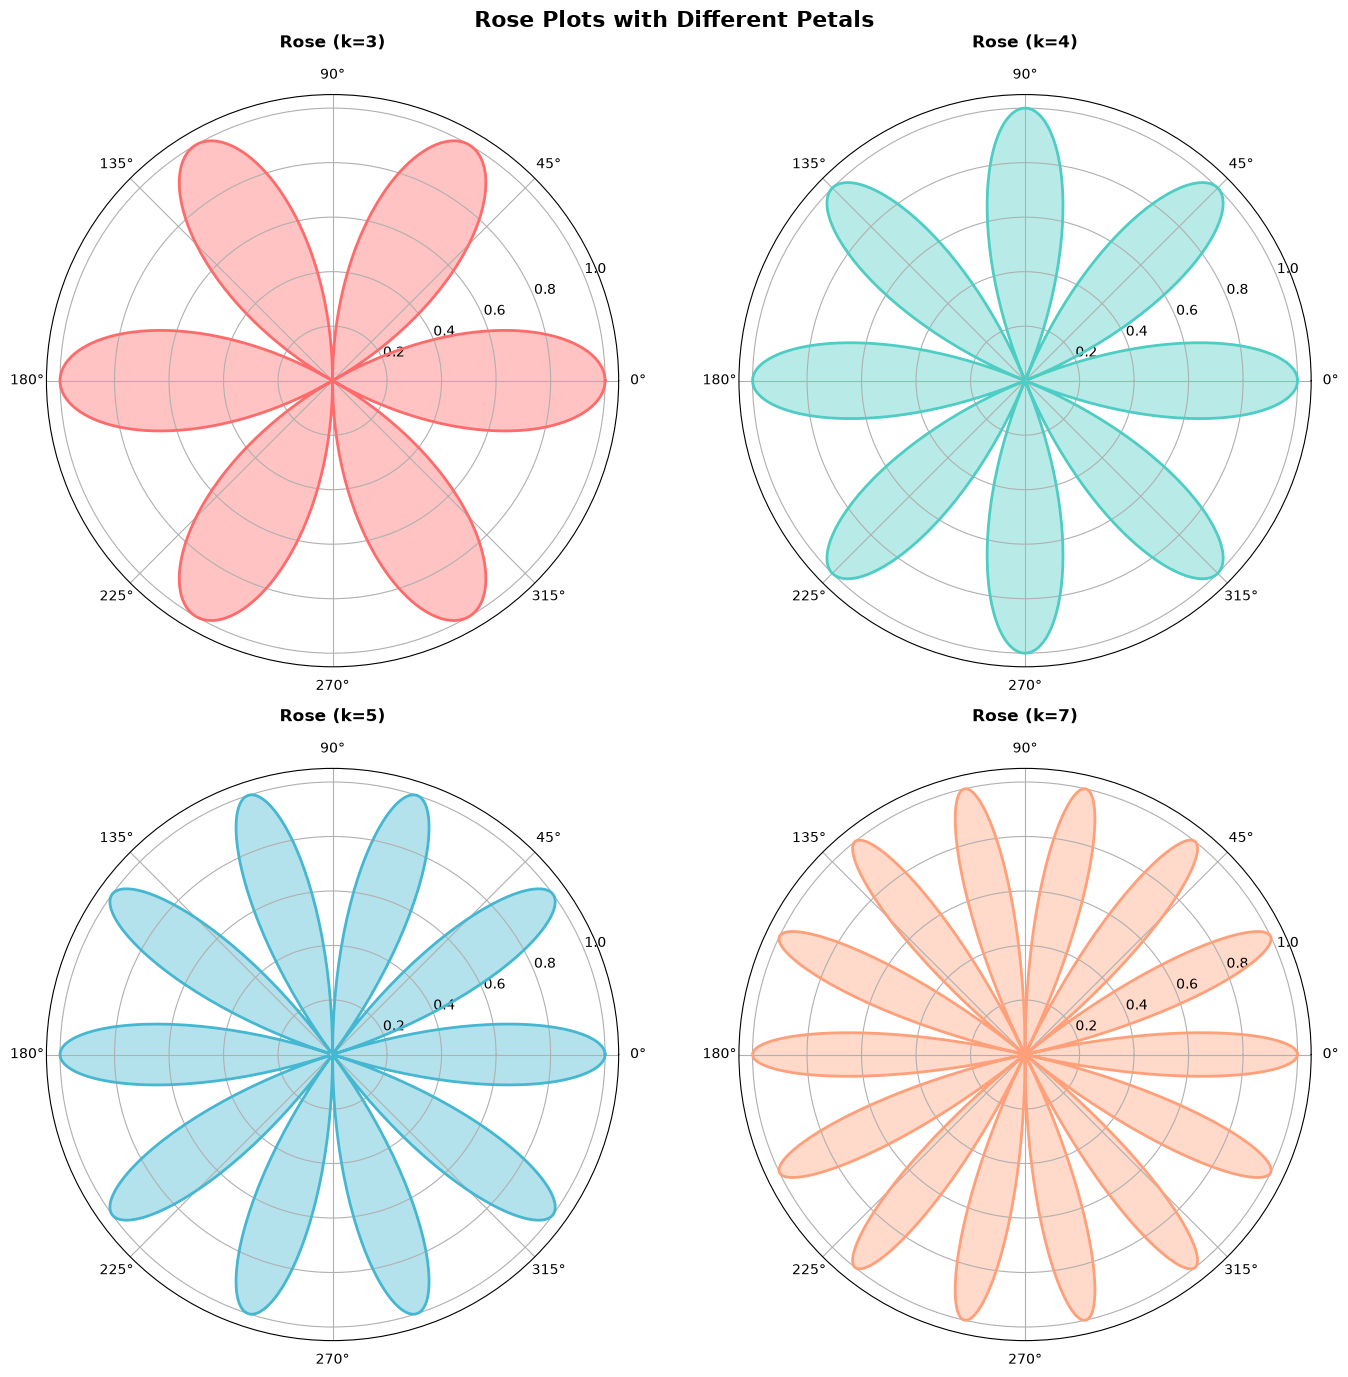

In [3]:
# Create multiple rose patterns
fig, axes = plt.subplots(2, 2, figsize=(14, 14), subplot_kw={'projection': 'polar'})
axes = axes.flatten()

patterns = [
    (3, 'Rose (k=3)'),
    (4, 'Rose (k=4)'),
    (5, 'Rose (k=5)'),
    (7, 'Rose (k=7)')
]

theta = np.linspace(0, 2*np.pi, 1000)
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

for ax, (k, title), color in zip(axes, patterns, colors):
    r = np.abs(np.cos(k * theta))
    ax.plot(theta, r, linewidth=2, color=color)
    ax.fill(theta, r, alpha=0.4, color=color)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=15)
    ax.grid(True)

plt.suptitle('Rose Plots with Different Petals', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

## 🌀 3. Spiral Patterns

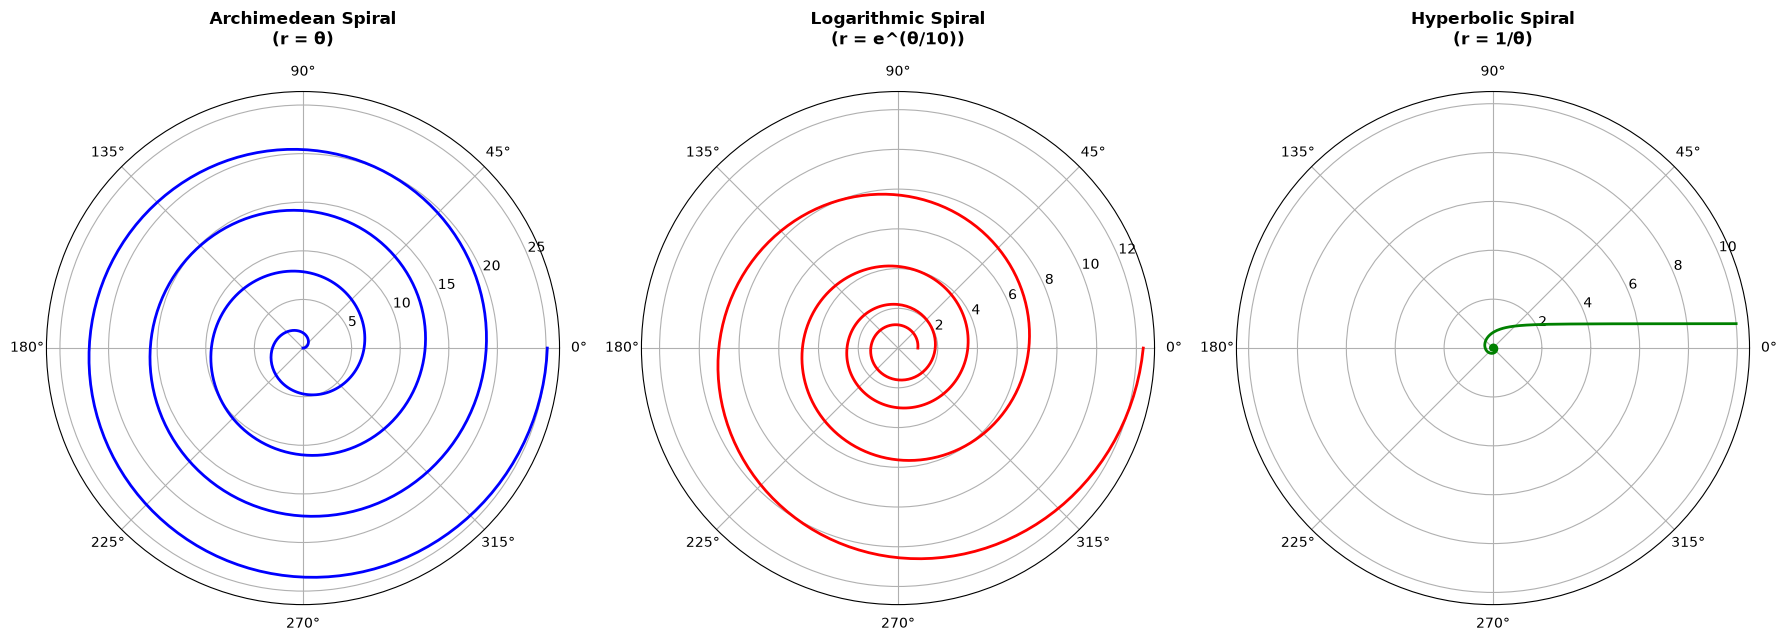

In [4]:
# Create different spiral patterns
fig, axes = plt.subplots(1, 3, figsize=(18, 6), subplot_kw={'projection': 'polar'})

theta = np.linspace(0, 8*np.pi, 500)

# Archimedean spiral
r1 = theta
axes[0].plot(theta, r1, 'b-', linewidth=2)
axes[0].set_title('Archimedean Spiral\n(r = θ)', fontsize=12, fontweight='bold', pad=15)
axes[0].grid(True)

# Logarithmic spiral
r2 = np.exp(theta/10)
axes[1].plot(theta, r2, 'r-', linewidth=2)
axes[1].set_title('Logarithmic Spiral\n(r = e^(θ/10))', fontsize=12, fontweight='bold', pad=15)
axes[1].grid(True)

# Hyperbolic spiral
theta_hyper = np.linspace(0.1, 8*np.pi, 500)
r3 = 1 / theta_hyper
axes[2].plot(theta_hyper, r3, 'g-', linewidth=2)
axes[2].set_title('Hyperbolic Spiral\n(r = 1/θ)', fontsize=12, fontweight='bold', pad=15)
axes[2].grid(True)

plt.tight_layout()
plt.show()

## 🌬️ 4. Wind Rose (Directional Data)

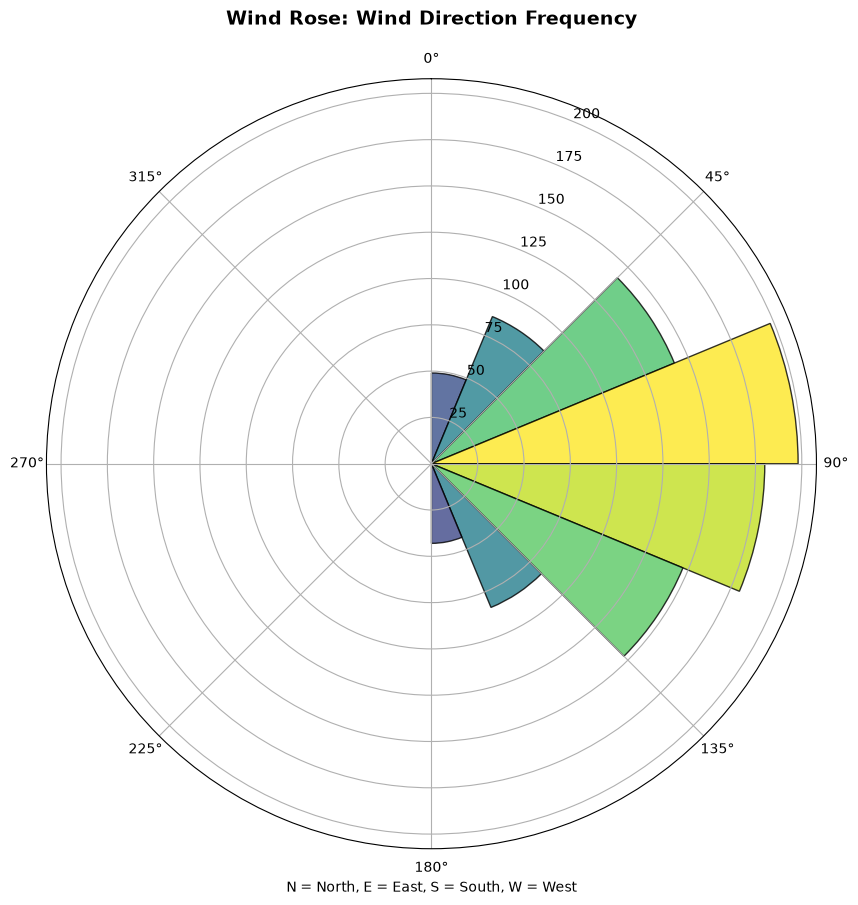

In [5]:
# Simulate wind direction and speed data
np.random.seed(42)
n = 1000
wind_directions = np.random.vonmises(np.pi/2, 2, n)  # Concentrated around 90°
wind_speeds = np.random.gamma(2, 2, n)

# Create histogram bins
n_bins = 16
theta_bins = np.linspace(0, 2*np.pi, n_bins+1)
theta_centers = (theta_bins[:-1] + theta_bins[1:]) / 2

# Calculate frequency in each direction
hist, _ = np.histogram(wind_directions, bins=theta_bins)
width = 2*np.pi / n_bins

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='polar')

# Create bar chart in polar coordinates
bars = ax.bar(theta_centers, hist, width=width, bottom=0, 
              color=plt.cm.viridis(hist / hist.max()), 
              edgecolor='black', linewidth=1, alpha=0.8)

ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_title('Wind Rose: Wind Direction Frequency', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('N = North, E = East, S = South, W = West', fontsize=10)

plt.show()

## 📊 5. Radar Chart (Spider Plot)

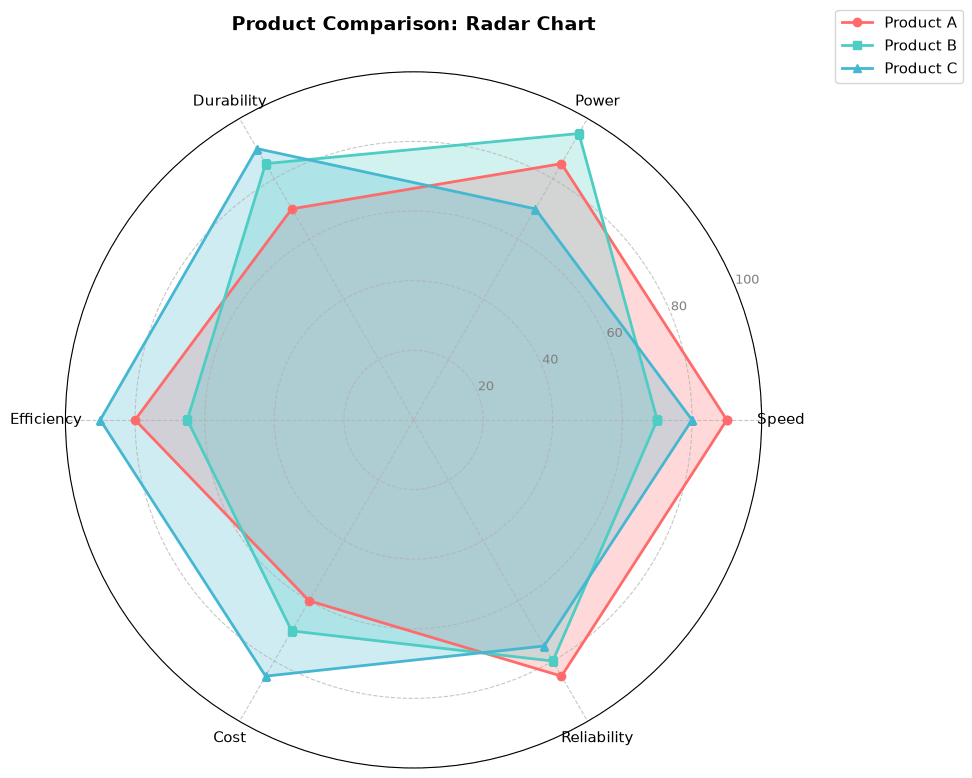

In [6]:
# Create radar chart for comparing multiple items
categories = ['Speed', 'Power', 'Durability', 'Efficiency', 'Cost', 'Reliability']
n_cats = len(categories)

# Data for three products
product_a = [90, 85, 70, 80, 60, 85]
product_b = [70, 95, 85, 65, 70, 80]
product_c = [80, 70, 90, 90, 85, 75]

# Compute angle for each category
angles = np.linspace(0, 2*np.pi, n_cats, endpoint=False).tolist()

# Complete the circle
product_a += product_a[:1]
product_b += product_b[:1]
product_c += product_c[:1]
angles += angles[:1]

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='polar')

# Plot data
ax.plot(angles, product_a, 'o-', linewidth=2, label='Product A', color='#FF6B6B')
ax.fill(angles, product_a, alpha=0.25, color='#FF6B6B')

ax.plot(angles, product_b, 's-', linewidth=2, label='Product B', color='#4ECDC4')
ax.fill(angles, product_b, alpha=0.25, color='#4ECDC4')

ax.plot(angles, product_c, '^-', linewidth=2, label='Product C', color='#45B7D1')
ax.fill(angles, product_c, alpha=0.25, color='#45B7D1')

# Fix axis labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 100)
ax.set_yticks([20, 40, 60, 80, 100])
ax.set_yticklabels(['20', '40', '60', '80', '100'], fontsize=9, color='gray')
ax.grid(True, linestyle='--', alpha=0.7)

ax.set_title('Product Comparison: Radar Chart', fontsize=14, fontweight='bold', pad=30)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)

plt.tight_layout()
plt.show()

## 🔄 6. Circular Histogram

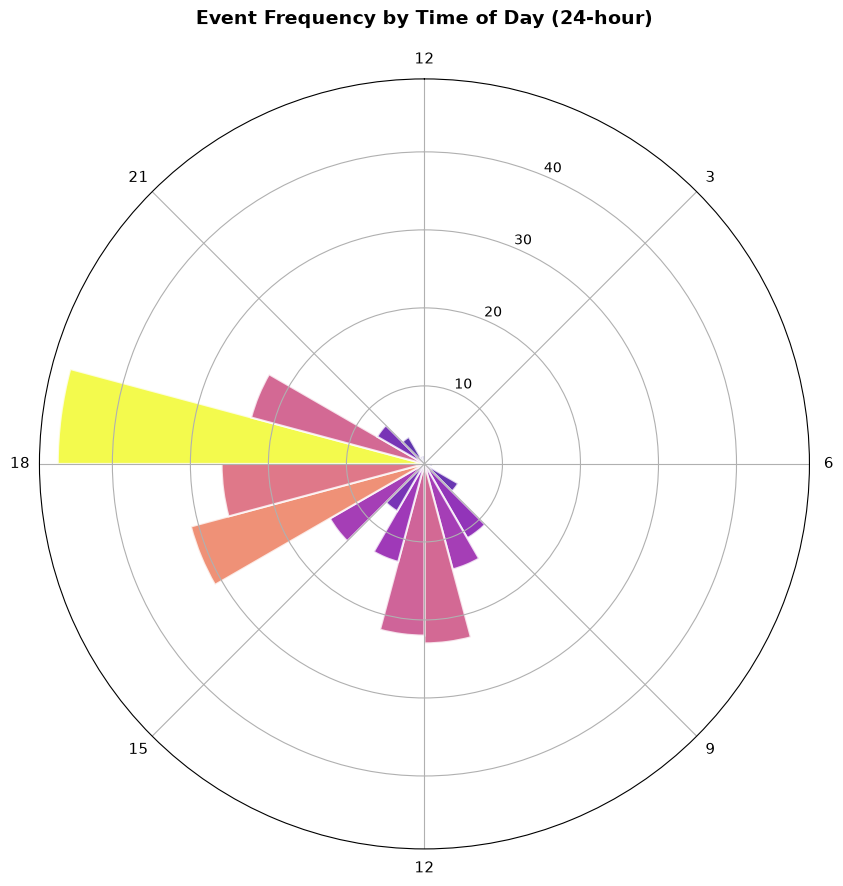

In [7]:
# Simulate time-of-day data (e.g., when events occur)
np.random.seed(42)
# Events concentrated around noon and evening
times = np.concatenate([
    np.random.normal(12, 2, 100) % 24,  # Lunch time events
    np.random.normal(18, 1.5, 150) % 24  # Evening events
])

# Convert to radians
angles = (times / 24) * 2 * np.pi

# Create histogram
n_bins = 24
theta_bins = np.linspace(0, 2*np.pi, n_bins+1)
hist, _ = np.histogram(angles, bins=theta_bins)
theta_centers = (theta_bins[:-1] + theta_bins[1:]) / 2
width = 2*np.pi / n_bins

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='polar')

bars = ax.bar(theta_centers, hist, width=width, bottom=0,
              color=plt.cm.plasma(hist / hist.max()),
              edgecolor='white', linewidth=1.5, alpha=0.8)

# Set 0 degrees to top (12 o'clock)
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)  # Clockwise

# Set hour labels
hour_labels = ['12', '3', '6', '9', '12', '15', '18', '21']
ax.set_xticks(np.linspace(0, 2*np.pi, 8, endpoint=False))
ax.set_xticklabels(hour_labels, fontsize=11)

ax.set_title('Event Frequency by Time of Day (24-hour)', fontsize=14, fontweight='bold', pad=20)

plt.show()

## 🎯 Key Takeaways

- ✅ Use `projection='polar'` to create polar plots
- ✅ Polar plots are perfect for circular/periodic data
- ✅ Wind roses show directional frequency distributions
- ✅ Radar charts compare multiple variables across categories
- ✅ Set `theta_zero_location` to change 0° position
- ✅ Use `theta_direction` for clockwise/counterclockwise
- ✅ Rose plots beautifully visualize mathematical patterns

## 💡 Try It Yourself

1. Create wind roses from weather data
2. Build radar charts for product comparisons
3. Visualize time-of-day patterns
4. Plot directional data (compass bearings)
5. Explore mathematical spirals and patterns